#### Importación de librerías necesarias

In [220]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones

from IPython.display import display

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

#### Carga de Data

In [221]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")

#### Información inicial de Data

In [222]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [223]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [224]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

# Manipulación de Datos

In [225]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [226]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [227]:
# convertir SeniorCitizen a object para que sea categórico
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

* La variable objetivo que guiará nuestra exploración es el **Churn**.

# Análisis Exploratorio de Datos

### Análisis de completitud

In [229]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [230]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [231]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


### Análisis de valores duplicados

In [232]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

### Análisis de valores atípicos

In [233]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


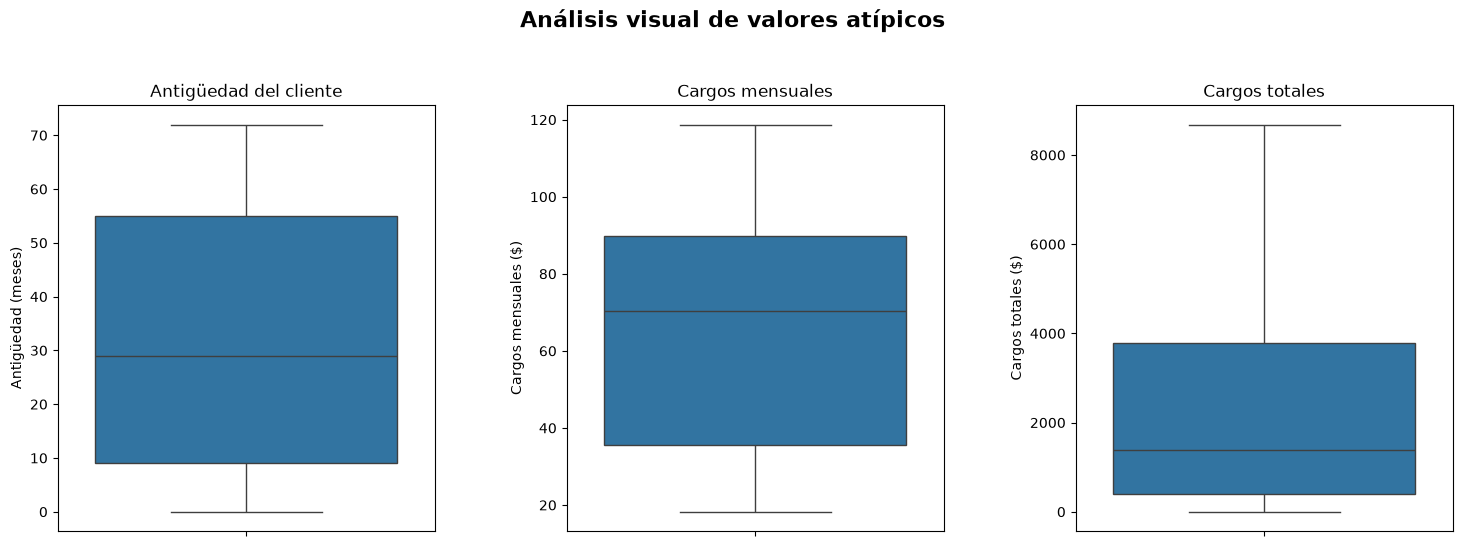

In [234]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antigüedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antigüedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

### Estadísticas básicas

In [235]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


* Hallazgos relevantes:

    - La distribución por género es equilibrada: hay 3555 hombres y 3488 mujeres
    - La clase positiva **Churn = Yes**, que representa a los clientes que sí abandonan el servicio, contiene 1869 registros (26,5%)
    - La mayoría de los clientes no son adultos mayores: **SeniorCitizen** = 0 representa aproximadamente el 83,8%
    - El contrato más frecuente es mensual, con 3875 clientes, lo que representa aproximadamente el 55%
    - Cerca del 90,3% de los clientes tiene servicio telefónico

In [236]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

## Análisis Descriptivo

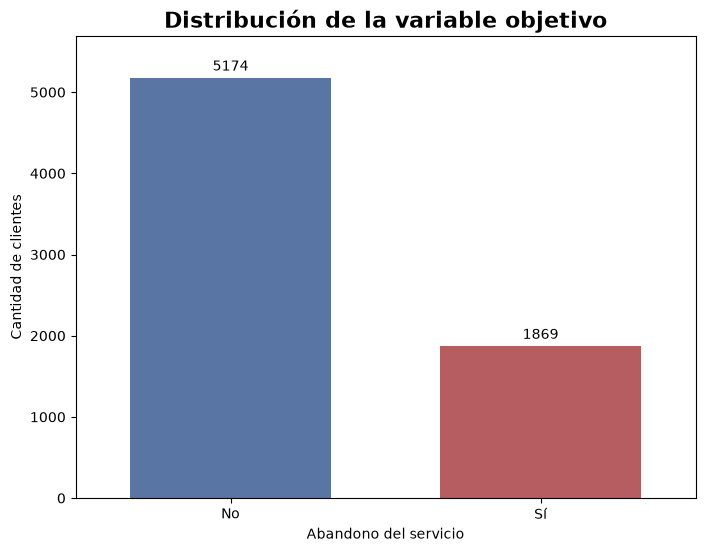

In [237]:
fig, ax = visualizaciones.graficar_distribucion_churn(
    df,
    ruta_salida="../resultados/plots/distribucion_variable_objetivo.png"
)
plt.show()

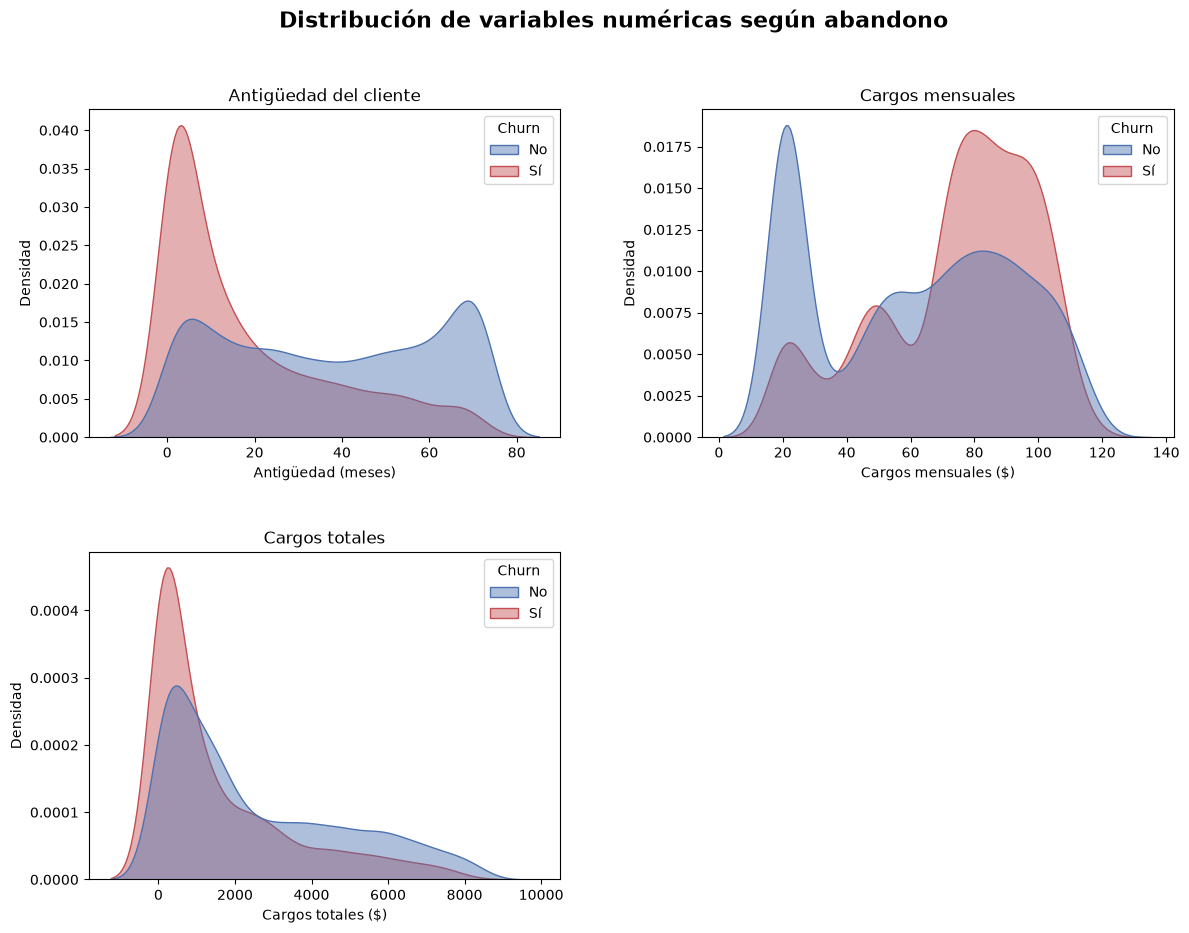

In [240]:
# generar curvas de densidad según la variable Churn
fig, axes = visualizaciones.graficar_curvas_densidad_churn(
    df,
    ruta_salida="../resultados/plots/curvas_densidad_churn.png"
)
plt.show()

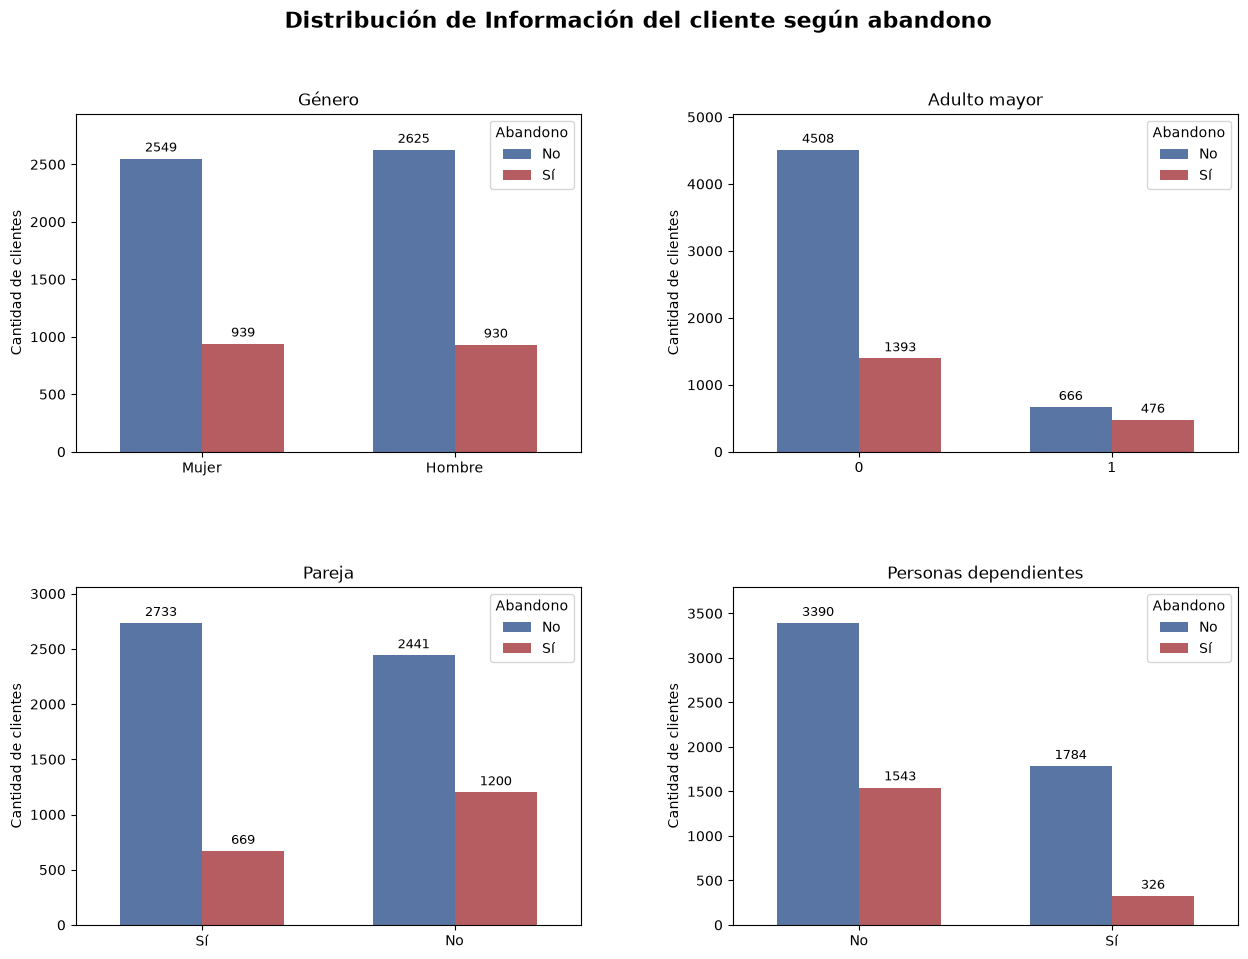

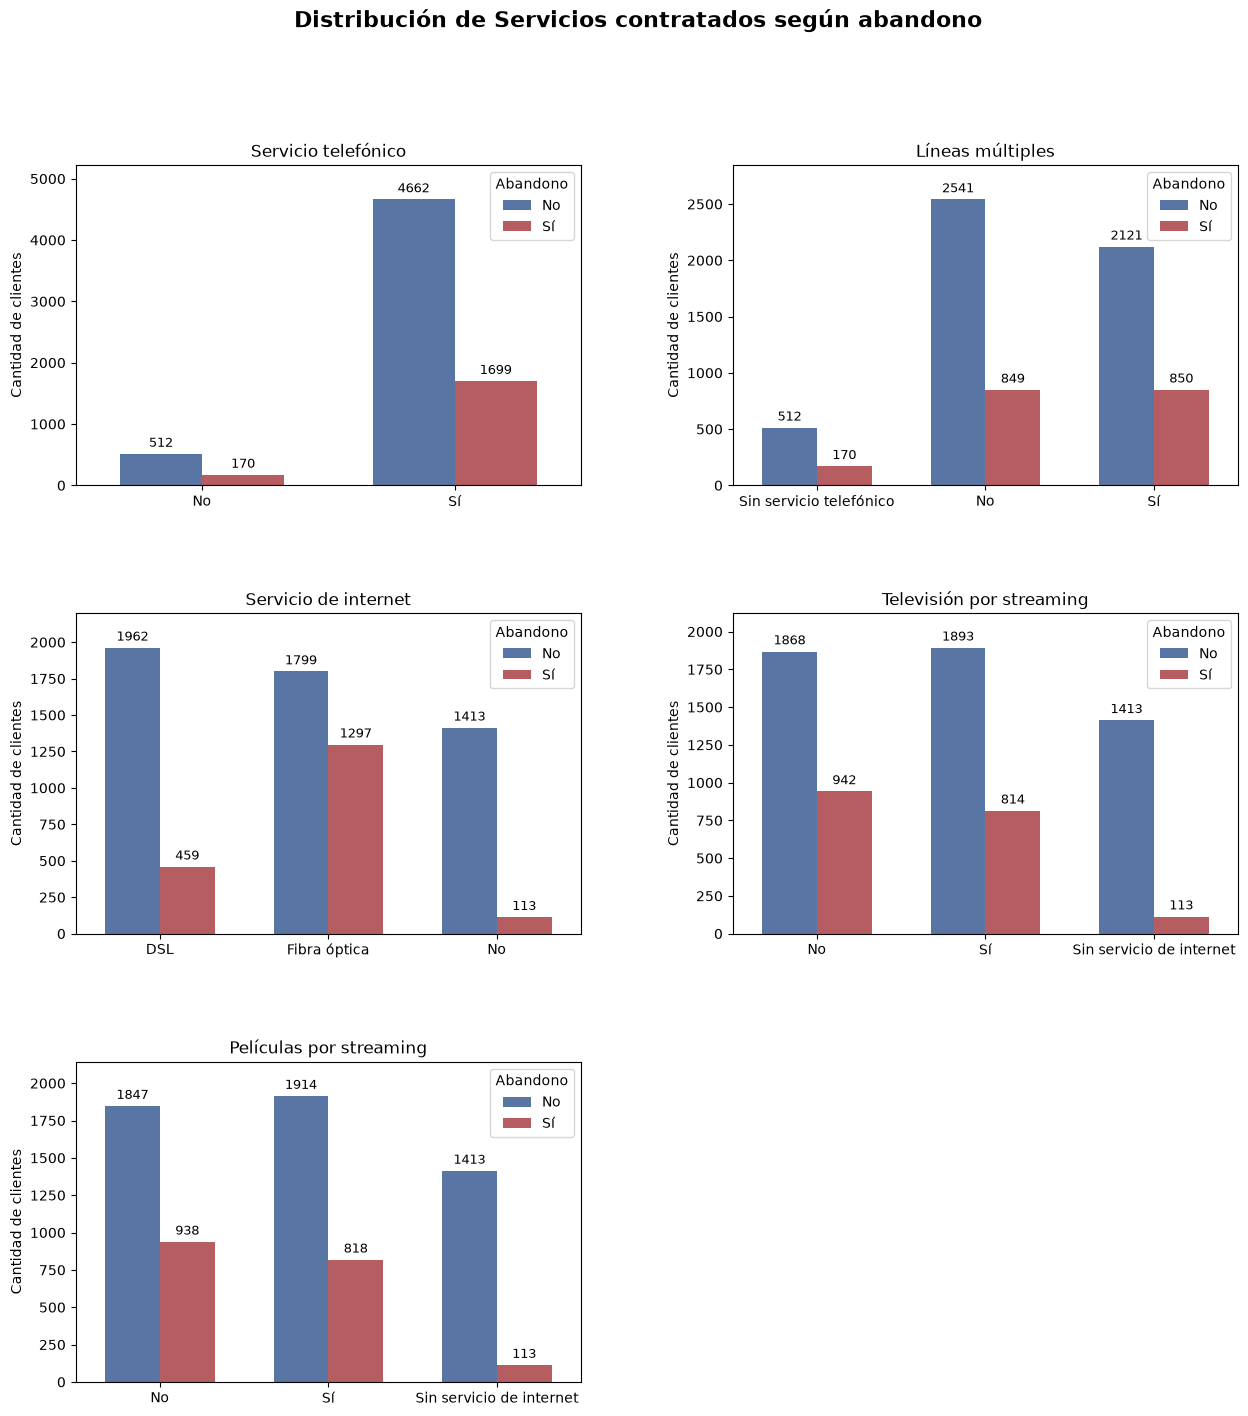

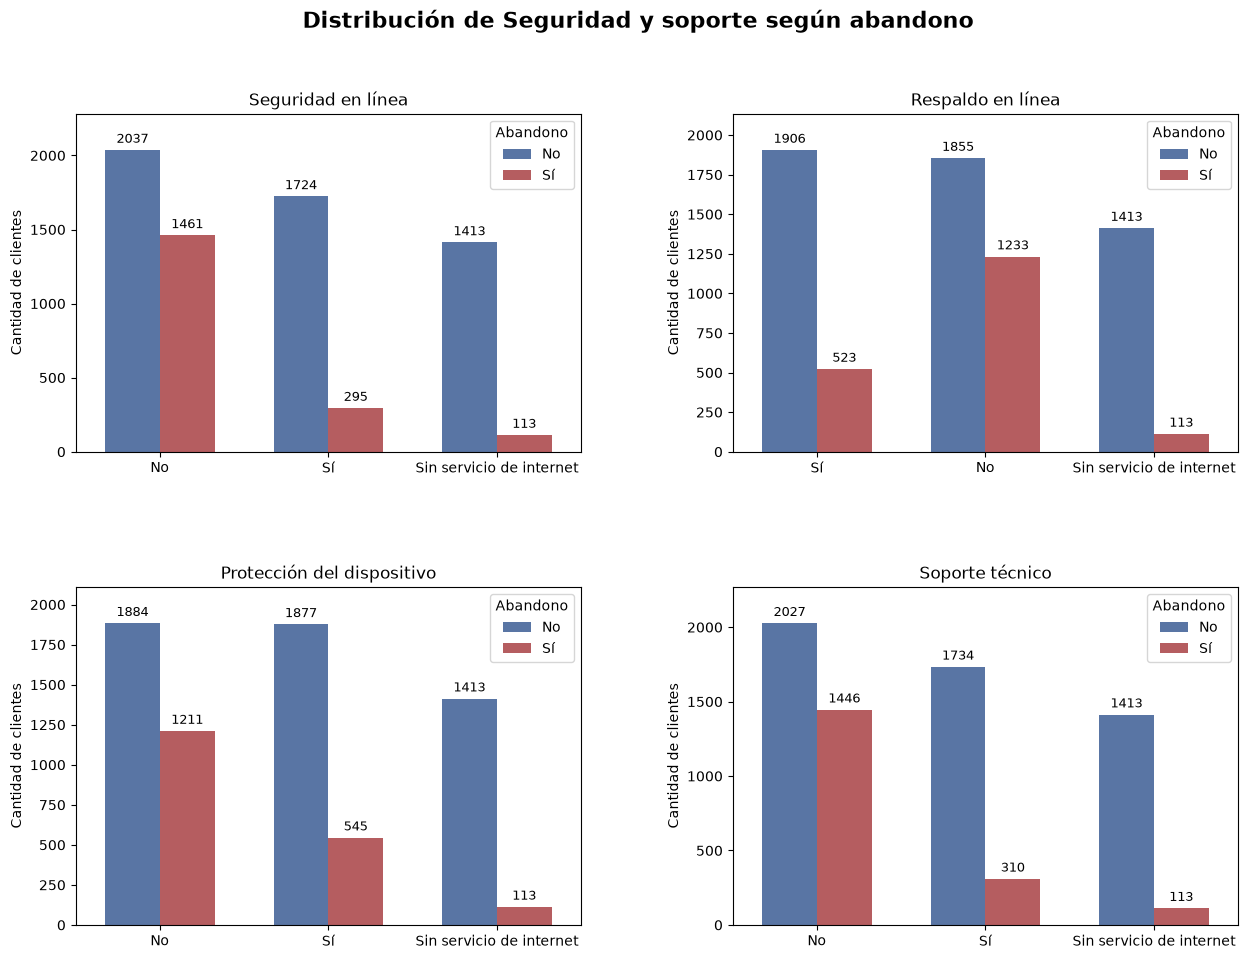

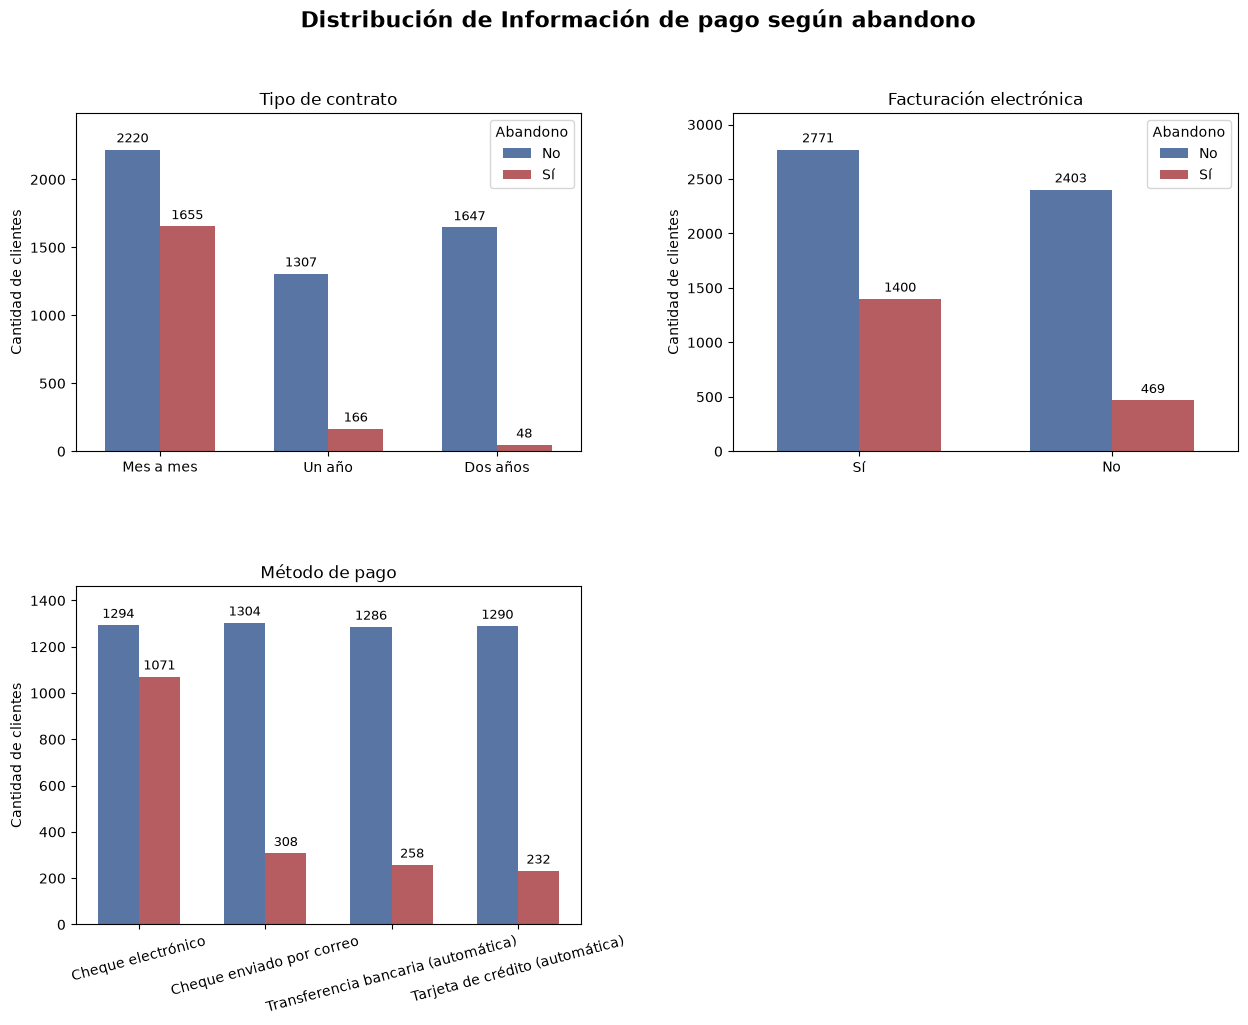

In [239]:
# generar visualizaciones categóricas agrupadas según la variable Churn
figuras = visualizaciones.graficar_grupos_categoricos_churn(
    df,
    ruta_salida="../resultados/plots"
)

for figura in figuras:
    display(figura)
    plt.close(figura)